In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import palava
import os
#import statsmodels.api as sm

import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib
from scipy.ndimage import median_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import igraph as ig


/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
!nvidia-smi

Thu May 22 19:25:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:CA:00.0 Off |                    0 |
| N/A   27C    P8             31W /  350W |       4MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Helper fucntions

def print_list(my_list):
  print("[", ", ".join(f"'{item}'" for item in my_list), "]")

def median_smooth_rows(arr, window_size=11):
    # Apply median filtering to each row of the array
    smoothed = np.apply_along_axis(lambda x: median_filter(x, size=window_size), axis=0, arr=arr)
    return smoothed




# Helper functions for the plots
def sort_based_on_first_row(matrix):
    sorted_indices = np.argsort(-matrix[0])
    # Rearrange the columns based on the sorted indices
    sorted_matrix = matrix[:, sorted_indices]
    return  sorted_matrix



def plot_multiple_ranks(data, colors=None, labels_offset=0.05, arrow_len=0, y_spacing=1, 
                        draw_uncolored_edges=True, title='', show_uncolored_nodes=True, 
                        color_legend=None, label_updates=None):
    """
    Plots ranked lists with connections and optional coloring, legend, and label updates.

    Parameters:
    - data: dict
        A dictionary where keys are list names and values are ranked lists.
    - colors: dict, optional
        A dictionary mapping items to colors.
    - labels_offset: float, optional
        Horizontal offset for text labels.
    - arrow_len: float, optional
        Arrowhead length for connections.
    - y_spacing: float, optional
        Vertical spacing between nodes.
    - draw_uncolored_edges: bool, optional
        Whether to draw edges for uncolored nodes.
    - title: str, optional
        Title for the plot.
    - show_uncolored_nodes: bool, optional
        Whether to display labels for uncolored nodes.
    - color_legend: dict, optional
        A dictionary mapping colors to legend labels (e.g., {'red': 'Beta', 'green': 'Delta'}).
    - label_updates: dict, optional
        A dictionary mapping old labels to new labels (e.g., {'gene2': 'GATA2'}).
    """
   
    keys = list(data.keys())  # Extract the keys from the dictionary
    num_lists = len(keys)  # Number of input lists
    fig, ax = plt.subplots(figsize=(17.5, 5))

    ax.set_xlim(0, num_lists + 1)  # Adjust x-limits based on the number of lists
    max_len = max(len(lst) for lst in data.values())  # Find the longest list for y-axis limits

    # Reverse the order of each list
    reversed_data = {key: lst[::-1] for key, lst in data.items()}

    # Calculate y-values for each reversed list
    y_values = [np.arange(1, len(reversed_data[key]) * y_spacing + 1, y_spacing) for key in keys]
    ax.set_ylim(0, max(len(lst) * y_spacing for lst in reversed_data.values()) + y_spacing)  # Set y-limits

    ax.axis('off')  # Remove axes

    # Draw arrows between the lists
    for i in range(num_lists - 1):  # Loop through each adjacent pair of lists
        current_list = reversed_data[keys[i]]
        next_list = reversed_data[keys[i + 1]]

        # Create a mapping from current list to next list
        current_to_next = [next_list.index(item) if item in next_list else None for item in current_list]

        for j in range(len(current_list)):
            if current_to_next[j] is not None:
                # Determine the color for the edge based on the current node color
                edge_color = colors.get(current_list[j], 'black') if colors else 'black'

                # Check if we should skip drawing this edge
                if edge_color == 'black' and not draw_uncolored_edges:
                    continue

                # Draw the arrow with the corresponding edge color
                ax.arrow(i + 1.02, y_values[i][j], 
                         0.96, y_values[i + 1][current_to_next[j]] - y_values[i][j], 
                         head_width=arrow_len, head_length=arrow_len, 
                         fc=edge_color, ec=edge_color, length_includes_head=True, linestyle=':', alpha=0.5)

    # Plot points for each reversed list
    for i, key in enumerate(keys):
        lst = reversed_data[key]
        for j in range(len(lst)):
            # Default to black for the points
            ax.plot(i + 1, y_values[i][j], 'o', markersize=2, color='black')  # Points
            
            # Determine the color for each gene, defaulting to black if not found
            text_color = colors.get(lst[j], 'black') if colors else 'black'
            
            # Update the label using label_updates if provided
            label = label_updates.get(lst[j], lst[j]) if label_updates else lst[j]
            
            # Show the node name only if the color is specified or if show_uncolored_nodes is True
            if text_color != 'black' or show_uncolored_nodes:
                ax.text(i + 1 - labels_offset, y_values[i][j], label, 
                        verticalalignment='center', horizontalalignment='right', color=text_color, fontsize=12)

        # Add key label at the bottom of each column
        ax.text(i + 1, -0.5, key, verticalalignment='top', horizontalalignment='center', fontsize=15)

    # Add title
    plt.title(title, fontsize=15)

    # Add legend if color_legend is provided
    if color_legend:
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in color_legend.items()]
        ax.legend(handles=legend_patches, loc='upper right', fontsize=12.5, title="Legend", bbox_to_anchor=(0.40, 0., 0.5, 0.6))

    plt.show()


def plot_multiple_ranks_supp(data, colors=None, labels_offset=0.1, arrow_len=0, y_spacing=1, 
                        draw_uncolored_edges=True, title='', show_uncolored_nodes=True, color_legend=None):
    """
    Plots ranked lists with connections and optional coloring and legend.
    
    Parameters:
    - data: dict
        A dictionary where keys are list names and values are ranked lists.
    - colors: dict, optional
        A dictionary mapping items to colors.
    - labels_offset: float, optional
        Horizontal offset for text labels.
    - arrow_len: float, optional
        Arrowhead length for connections.
    - y_spacing: float, optional
        Vertical spacing between nodes.
    - draw_uncolored_edges: bool, optional
        Whether to draw edges for uncolored nodes.
    - title: str, optional
        Title for the plot.
    - show_uncolored_nodes: bool, optional
        Whether to display labels for uncolored nodes.
    - color_legend: dict, optional
        A dictionary mapping colors to legend labels (e.g., {'red': 'Beta', 'green': 'Delta'}).
    """
    import numpy as np  # Import if not already in use
    import matplotlib.patches as mpatches  # For creating legend patches
    
    keys = list(data.keys())  # Extract the keys from the dictionary
    num_lists = len(keys)  # Number of input lists
    fig, ax = plt.subplots(figsize=(12.5, 17.5))
    
    ax.set_xlim(0, num_lists + 1)  # Adjust x-limits based on the number of lists
    max_len = max(len(lst) for lst in data.values())  # Find the longest list for y-axis limits
    
    # Reverse the order of each list
    reversed_data = {key: lst[::-1] for key, lst in data.items()}

    # Calculate y-values for each reversed list
    y_values = [np.arange(1, len(reversed_data[key]) * y_spacing + 1, y_spacing) for key in keys]
    ax.set_ylim(0, max(len(lst) * y_spacing for lst in reversed_data.values()) + y_spacing)  # Set y-limits
    
    ax.axis('off')  # Remove axes

    # Draw arrows between the lists
    for i in range(num_lists - 1):  # Loop through each adjacent pair of lists
        current_list = reversed_data[keys[i]]
        next_list = reversed_data[keys[i + 1]]
        
        # Create a mapping from current list to next list
        current_to_next = [next_list.index(item) if item in next_list else None for item in current_list]
        
        for j in range(len(current_list)):
            if current_to_next[j] is not None:
                # Determine the color for the edge based on the current node color
                edge_color = colors.get(current_list[j], 'black') if colors else 'black'
                
                # Check if we should skip drawing this edge
                if edge_color == 'black' and not draw_uncolored_edges:
                    continue
                
                # Draw the arrow with the corresponding edge color
                ax.arrow(i + 1.02, y_values[i][j], 
                         0.96, y_values[i + 1][current_to_next[j]] - y_values[i][j], 
                         head_width=arrow_len, head_length=arrow_len, 
                         fc=edge_color, ec=edge_color, length_includes_head=True, linestyle=':', alpha=0.25)

    # Plot points for each reversed list
    for i, key in enumerate(keys):
        lst = reversed_data[key]
        for j in range(len(lst)):
            # Default to black for the points
            ax.plot(i + 1, y_values[i][j], 'o', markersize=8, color='black')  # Points
            
            # Determine the color for each gene, defaulting to black if not found
            text_color = colors.get(lst[j], 'black') if colors else 'black'
            
            # Show the node name only if the color is specified or if show_uncolored_nodes is True
            if text_color != 'black' or show_uncolored_nodes:
                ax.text(i + 1 - labels_offset, y_values[i][j], lst[j], 
                        verticalalignment='center', horizontalalignment='right', color=text_color, fontsize=12.5)

        # Add key label at the bottom of each column
        ax.text(i + 1, -0.5, key, verticalalignment='top', horizontalalignment='center', fontsize=17.5)

    # Add title
    plt.title(title, fontsize=20)

    # Add legend if color_legend is provided
    if color_legend:
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in color_legend.items()]
        box = ax.get_position()
        ax.set_position([box.x0, box.y0 + box.height * 0.1,
                         box.width, box.height * 0.9])
        
        # Put a legend below current axis
        ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.05),
              fancybox=True, shadow=True, ncol=5)
    
    plt.show()



def plot_gene_expression_pseudotime(adata, gene_symbols, pseudotime_column, color_column, zero_frac_to_remove_lst = None, order=None, colns=3, title='', fontsize =  15):
    """
    Plots gene expression vs. pseudotime for a list of genes, with a LOWESS curve (with customizable `frac`) and scatter plot colored by a specified column.
    Displays the plots in a grid format.

    Parameters:
    - adata: AnnData object containing gene expression data in `X` and metadata in `obs`.
    - gene_symbols: List of strings, gene symbols to plot the expression of.
    - pseudotime_column: String, column name in `obs` for pseudotime data.
    - color_column: String, column name in `obs` for color coding the scatter plot.
    - lowess_frac: List of floats, one LOWESS smoothing parameter for each gene in `gene_symbols`.
    - order: List or None, custom ordering of cell labels for coloring the plot. If None, the default order is used.
    - colns: Integer, number of columns in the grid of plots.
    - title: String, optional, overarching title for the grid of plots.
    """
    # Check if all gene_symbols exist in adata.var
    if zero_frac_to_remove_lst is None:
        zero_frac_to_remove_lst = [0.5] * len(gene_symbols)
    missing_genes = [gene for gene in gene_symbols if gene not in adata.var_names]
    if missing_genes:
        raise ValueError(f"Gene symbol(s) {missing_genes} not found in adata.var_names.")
    
    # Check if the number of lowess_frac values matches the number of genes
    if len(zero_frac_to_remove_lst) != len(gene_symbols):
        raise ValueError("The length of `zero_frac_to_remove_lst` must match the length of `gene_symbols`.")
    
    # Calculate the number of rows needed for the grid
    rows = -(-len(gene_symbols) // colns)  # Ceiling division to get number of rows
    
    # Create the grid of subplots
    fig, axes = plt.subplots(rows, colns, figsize=(colns * 5, rows * 3), constrained_layout=True)
    axes = axes.flatten()  # Flatten the axes array for easy indexing
    total_subplots = len(gene_symbols)

    # Number of plots in the last row
    last_row_subplots = total_subplots - (total_subplots % colns if total_subplots % colns != 0 else colns)
    # Loop through each gene and create a plot
    for idx, (gene_symbol, zero_frac_to_remove) in enumerate(zip(gene_symbols, zero_frac_to_remove_lst)):
        # Extract gene expression, pseudotime, and color data
        gene_idx = np.where(adata.var_names == gene_symbol)[0][0]
        gene_expression = adata.X[:, gene_idx].toarray().flatten() if hasattr(adata.X, 'toarray') else adata.X[:, gene_idx].flatten()
        pseudotime = adata.obs[pseudotime_column]
        color_data = adata.obs[color_column]
        
        gene_ind  = np.where(((gene_expression!=0) | np.random.binomial(1, 1.0 - zero_frac_to_remove, gene_expression.shape).astype(bool)))[0]
        gene_expression = gene_expression[gene_ind] 
        pseudotime = pseudotime[gene_ind]
        color_data = color_data[gene_ind]

        
        # If order is provided, reorder the color_data accordingly
        if order is not None:
            color_data = pd.Categorical(color_data, categories=order, ordered=True)
            
        # Create a dataframe for plotting
        df = pd.DataFrame({
            'gene_expression': gene_expression,
            'pseudotime': pseudotime,
            'color_data': color_data
        })

        # Plot scatterplot with custom order if specified
        ax = axes[idx]
        sns.scatterplot(
            x='pseudotime', 
            y='gene_expression', 
            hue='color_data', 
            data=df, 
            palette='bright', 
            s=5, 
            hue_order=order, 
            alpha=0.5, 
            ax=ax
        )
        
        # Fit and plot LOWESS curve with the specified smoothing parameter
        lowess = sm.nonparametric.lowess(df['gene_expression'], df['pseudotime'], frac = 0.15)
        ax.plot(lowess[:, 0], lowess[:, 1].clip(min = 0), color='black', linewidth=1, label='LOWESS')
        
        # Customize plot
        # ax.set_title(f'{gene_symbol} Expression')
        if idx >= last_row_subplots:
            ax.set_xlabel('Pseudotime', fontsize =fontsize) 
        else:  
            ax.set_xlabel('')
            
        ax.set_ylabel(f'{gene_symbol} Expression', fontsize = fontsize)
        if idx ==0 : ax.legend(markerscale = 5.0)
        else: ax.legend().remove()

    # Remove any unused axes if the number of genes < grid size
    for idx in range(len(gene_symbols), len(axes)):
        fig.delaxes(axes[idx])

    # Add an overarching title if provided
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.show()

def plot_pca_panels(adata, pc_pairs, figsize=(10, 8), color_by="cell.labels", main_title=None, fontsize = 20):
    """
    Plot PCA panels from an AnnData object.

    Parameters:
    -----------
    adata : AnnData
        The AnnData object containing PCA results.
    pc_pairs : list of str
        List of strings indicating which PCs to plot, e.g., ["1,2", "3,4"].
    figsize : tuple, optional
        Figure size for the plot (default: (10, 8)).
    color_by : str, optional
        Key in `adata.obs` to color the points (default: "cell.labels").
    main_title : str, optional
        Title for the entire figure (default: None).

    Returns:
    --------
    None
        Displays the plot.
    """
    # Check if PCA results are available
    if "X_pca" not in adata.obsm:
        raise ValueError("PCA results not found in `adata.obsm`. Ensure PCA has been computed.")
    
    # Extract PCA coordinates
    pca_coords = adata.obsm["X_pca"]
    
    # Prepare the figure
    n_panels = len(pc_pairs)
    n_rows = int(np.ceil(n_panels / 2))
    fig, axes = plt.subplots(n_rows, 2, figsize=figsize)
    axes = axes.flatten()

    # Determine if `color_by` is numeric or categorical
    if color_by in adata.obs:
        color_values = adata.obs[color_by]
        if pd.api.types.is_categorical_dtype(color_values):
            is_numeric = False
        else:
            is_numeric = np.issubdtype(color_values.dtype, np.number)
    else:
        raise ValueError(f"{color_by} not found in `adata.obs`.")
    
    # Loop through PC pairs and plot
    for idx, pc_pair in enumerate(pc_pairs):
        if idx >= len(axes):  # Stop if exceeding available axes
            break
        ax = axes[idx]
        pcs = [int(x) - 1 for x in pc_pair.split(",")]
        
        if is_numeric:
            # Scatter plot for the current PC pair with numeric color values
            scatter = ax.scatter(
                pca_coords[:, pcs[0]],
                pca_coords[:, pcs[1]],
                c=color_values,
                cmap="viridis",  # Color map for numeric data
                alpha=0.75,
                s=1,
                edgecolor='none'
            )
            cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
            if idx < len(pc_pairs) - 1:
                cbar.remove()
            cbar.set_label('')
        else:
            # For categorical data, create a color palette
            palette = sns.color_palette("tab10", n_colors=len(color_values.cat.categories))
            cmap = ListedColormap(palette)  # Convert palette to ListedColormap
            scatter = ax.scatter(
                pca_coords[:, pcs[0]],
                pca_coords[:, pcs[1]],
                c=color_values.cat.codes,  # Convert categories to codes
                cmap=cmap,  # Use ListedColormap
                alpha=0.75,
                s=1,
                edgecolor='none'
            )
            ax.legend(*scatter.legend_elements(), title=color_by, loc='best', fontsize='small')
        
        ax.set_xlabel(f"PC{pcs[0] + 1}", fontsize=fontsize - 5)
        ax.set_ylabel(f"PC{pcs[1] + 1}", fontsize=fontsize - 5)

    # Hide unused subplots
    for idx in range(len(pc_pairs), len(axes)):
        fig.delaxes(axes[idx])
    
    # Add a main title if provided
    if main_title:
        fig.suptitle(main_title, fontsize=fontsize, y=0.95)

    plt.tight_layout()
    plt.show()

def scale_rows_zero_one(matrix):
    """
    Scales each row of a matrix to be between 0 and 1.
    
    Parameters:
        matrix (np.ndarray): Input 2D array.
    
    Returns:
        np.ndarray: Row-wise scaled matrix.
    """
    min_vals = matrix.min(axis=1, keepdims=True)
    max_vals = matrix.max(axis=1, keepdims=True)
    # Avoid division by zero
    scaled = (matrix - min_vals) / (max_vals - min_vals + 1e-8)
    return scaled


In [5]:


adata = sc.read('data/iPSC_with_pathways_cell_metadata_and_stages.h5ad') 
pathways = [torch.tensor(i) for i in adata.uns['pathways_9000hvg']]

adata


AnnData object with n_obs × n_vars = 36044 × 9000
    obs: 'cell_differentiation'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'pathway_names', 'pathways_9000hvg'
    obsm: 'PC1_top1000hvgs', 'PC1_top100hvgs', 'PC1_top2000hvgs', 'PC1_top200hvgs', 'PC1_top500hvgs', 'assigned', 'auxDir', 'cell_filter', 'cell_name', 'compatible_fragment_ratio', 'day', 'donor', 'donor_long_id', 'donor_short_id', 'expected_format', 'experiment', 'frag_dist_length', 'gc_bias_correct', 'is_cell_control', 'is_cell_control_bulk', 'is_cell_control_control', 'libType', 'library_types', 'log10_total_counts', 'log10_total_counts_ERCC', 'log10_total_counts_MT', 'log10_total_counts_endogenous', 'log10_total_counts_feature_control', 'log10_total_features', 'log10_total_features_ERCC', 'log10_total_features_MT', 'log10_total_features_endogenous', 'log10_total_features_feature_control', 'mapping_type', 'mates1', 'mates2', 'n_alt_reads', 'n_total_reads', 'num_

In [6]:
sc.tl.pca(adata)

In [7]:
num_unann = int(40)

pathway_names = adata.uns['pathway_names']
num_ann = pathway_names.shape[0]
pathway_names_plot = [pathway_names[i].replace('_', ' ' ).capitalize() + ' ['+str(i)+']'  for i in range(len(pathway_names))] + ['Unannotated factor '+ str(i + 1) + ' ['+str(i+num_ann)+']'  for i in range(num_unann)]


In [8]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


# To look for the model with the smalled ELBO
for i in [0, 1, 2, 3,4]:
    dr = f'Out_files_and_results/old_ipsc_data_9k_2by3_lam_for_uann/seed={i}_lambda=0.4_lambda_marker_genes=0.1_palava_width=25_list_of_nonlin_factors=none'
    scvi_palava = SCVI_palava.load(file = dr+'/latent_and_slope_data/scvi_model', adata = adata)
    print(i, scvi_palava.history['elbo_train'].iloc[[849]])

In [22]:

dr = 'saved_models/seed=1_lambda=0.4_lambda_marker_genes=0.1_palava_width=25_list_of_nonlin_factors=0-1-2-16-21'


In [23]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [24]:
scvi_palava = SCVI_palava.load(file = dr+'/latent_and_slope_data/scvi_model', adata = adata)

factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]
factor_importance = factor_importance_dict['factor_importance']

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/ssanthoshkum/.local/lib/python3.10/site-pa ...
  rank_zero_warn(
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/model/base/_utils.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipp

Number of latent variables = 94: 54 annotated + 40 unannotated


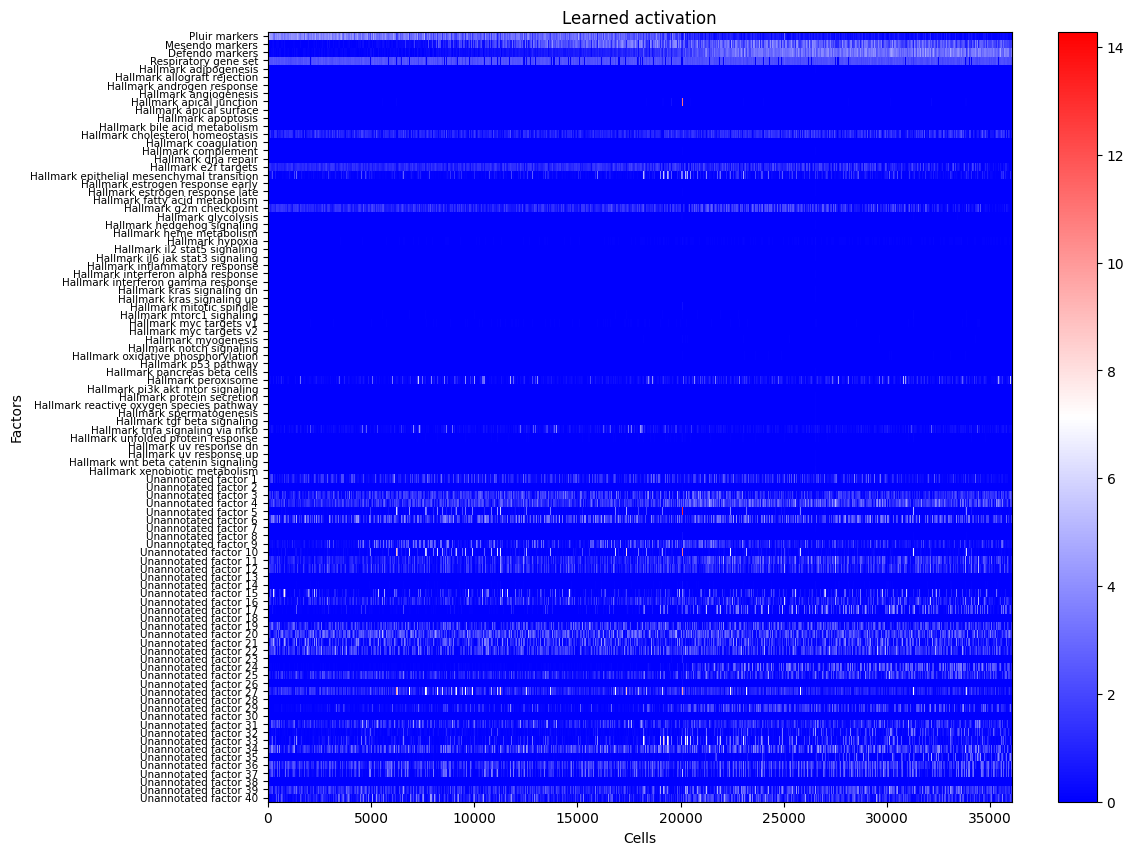

In [25]:
learned_activations = scvi_palava.get_latent_representation()

inds =np.argsort(adata.obsm['pseudo'])

pathway_names_plot_pres = [pathway_names[i].replace('_', ' ' ).capitalize()  for i in range(len(pathway_names))] + ['Unannotated factor '+ str(i + 1)   for i in range(num_unann)]

fig, ax = plt.subplots(figsize=(12, 10))

plt.imshow(learned_activations[inds,:].T,   aspect = 'auto', cmap='bwr', interpolation = 'none', rasterized=True)
plt.title("Learned activation")
plt.xlabel('Cells')
plt.ylabel('Factors')
_ = plt.yticks([i for i in range(len(pathway_names_plot_pres))], pathway_names_plot_pres, fontsize = 7.5)
cbar = plt.colorbar()
plt.show()
plt.close()


# Manuscript plot

['Hallmark mitotic spindle [33]']


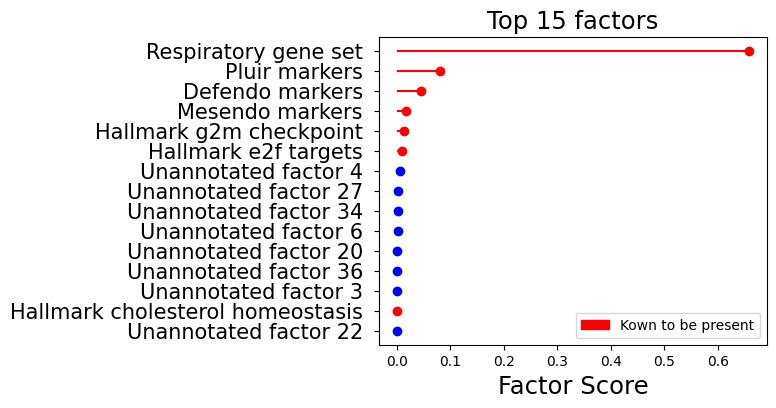

In [27]:

factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]
factor_importance = factor_importance_dict['factor_importance']

highlighted_pathways =  ['Pluir markers [0]', 'Mesendo markers [1]', 'Defendo markers [2]','Respiratory gene set [3]', 'Hallmark e2f targets [16]', 'Hallmark cholesterol homeostasis [12]', 'Hallmark g2m checkpoint [21]','Hallmark mitotic spindle [33]']


index_asc_order = np.argsort(factor_importance)[::-1][:15][::-1]

print([x for x in highlighted_pathways if x not in np.array(pathway_names_plot)[index_asc_order]])

plt.figure(figsize=(5, 4))
for i, idx in enumerate(index_asc_order):
    pathway_name = pathway_names_plot[idx]
    color = 'r' if pathway_name in highlighted_pathways else 'b'
    plt.stem([pathway_name.split('[')[0]], [factor_importance[idx]], markerfmt=color+'o', linefmt=color+'-', orientation='horizontal')

plt.title('Top 15 factors', fontsize =17.5)
plt.xlabel('Factor Score', fontsize =17.5)
plt.tick_params(axis='y', which='major', labelsize=15)
            
red_patch = mpatches.Patch(color='red', label='Kown to be present')
blue_patch = mpatches.Patch(color='blue', label='Not known to be present')
plt.legend(handles=[red_patch], loc='lower right', title='')
plt.show()




# Manuscript plot

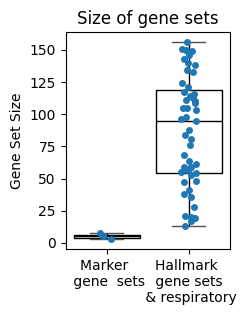

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your data
data_ = pd.DataFrame({
    'gene_set_size': [int(i.sum()) for i in pathways],
    'gene_set_type': ['Marker \n gene  sets']*3 + ['Hallmark \n gene sets \n & respiratory']*51
})
plt.figure(figsize=(2.5, 3.25))
# Scatter-style plot
sns.stripplot(data=data_, y='gene_set_size', x='gene_set_type', jitter=True, dodge=True)
# Plot transparent boxplot outline
sns.boxplot(
    data=data_,
    y='gene_set_size',
    x='gene_set_type',
    showcaps=True,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},  # no fill, black border
    whiskerprops={'color': 'black'},
    medianprops={'color': 'black'},
    flierprops={'marker': ''},  # hide outliers from boxplot
)

# Optional styling
plt.ylabel('Gene Set Size')
plt.xlabel('')
plt.title('Size of gene sets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


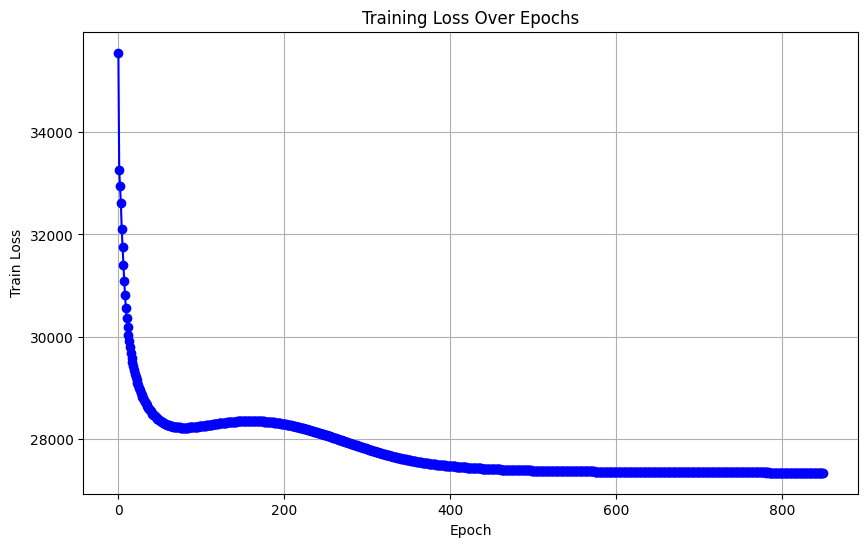

In [87]:

metric_to_plot = 'elbo_train'
df = scvi_palava.history[metric_to_plot]

plt.figure(figsize=(10, 6))

plt.plot(df.index, df[metric_to_plot], marker='o', linestyle='-', color='b')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.grid(True)
plt.show()

In [16]:

med_libsize = np.median(np.sum(adata.X, axis = 1))
print("Median library size is " + str(med_libsize))
adata_norm = sc.pp.normalize_per_cell(adata, counts_per_cell_after = med_libsize, copy = True)
adata_norm = sc.pp.log1p(adata_norm, copy = True)

sc.tl.pca(adata_norm, n_comps=6)

Median library size is 399785.88


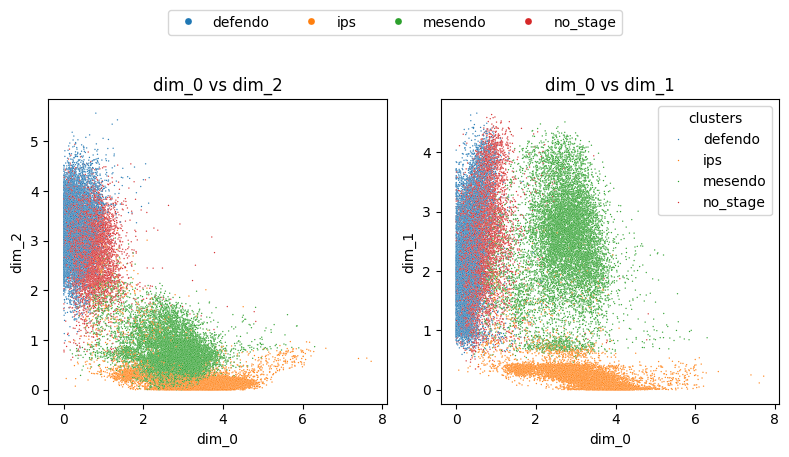

In [17]:
learned_activations = scvi_palava.get_latent_representation()
plot_df = pd.DataFrame({
        f'dim_0': learned_activations[:,0].flatten(),
        f'dim_1': learned_activations[:,1].flatten(),
        f'dim_2': learned_activations[:,2].flatten(),
       f'dim_unann': learned_activations[:,53+29].flatten(),
    'clusters': adata_norm.obs['cell_differentiation']
    })
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))  # 2 plots side by side

# First scatterplot (dim_0 vs dim_2)
sns.scatterplot(data=plot_df, x='dim_0', y='dim_2', s=1, hue='clusters', ax=axes[0], rasterized=True)
axes[0].set_title('dim_0 vs dim_2')
axes[0].legend_.remove()  # Optional: remove duplicate legends

# Second scatterplot (dim_0 vs dim_1)
sns.scatterplot(data=plot_df, x='dim_0', y='dim_1', s=1, hue='clusters', ax=axes[1], rasterized=True)
axes[1].set_title('dim_0 vs dim_1')

# Single shared legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05), markerscale = 5)

plt.tight_layout()
plt.show()
plt.close()

In [90]:
adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)

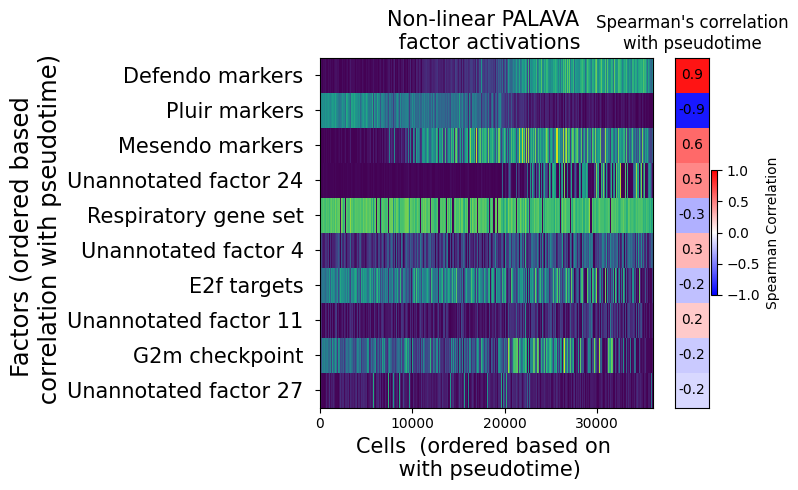

In [18]:

adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)
#subset based on top 30 factors 
n_top_fac = 30

index_asc_order = np.argsort(factor_importance)[::-1][:n_top_fac]
learned_activations_n_top_facs = learned_activations[index_asc_order,:]

pathway_names_plot_n_top_facs = [pathway_names_plot[i] for i in index_asc_order]

fac = 2
i = fac  # Index of HEME factor 

ind_sort = np.argsort(adata.obsm['pseudo'])

correlations_ = np.array([np.abs(spearmanr(adata.obsm['pseudo'], row).correlation) for row in learned_activations_n_top_facs])

n_top = 10
subset_indx = np.argsort(correlations_)[::-1][:n_top]
data = learned_activations_n_top_facs[subset_indx, :] # Replace with your actual data

# Index of the row to compare with
pathway_names_plot_subset = [pathway_names_plot_n_top_facs[i] for i in subset_indx]

# Compute Spearman's correlation for each row with the target row

correlations = np.array([spearmanr(adata.obsm['pseudo'], row).correlation for row in data])#np.array([spearmanr(target_row, row).correlation for row in data])

# Plot the data matrix and the Spearman correlation side by side, the tied observations receive the same average rank
fig, axes = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [4, 0.5]})

# Plot the data matrix on the left
im = axes[0].imshow(scale_rows_zero_one(data[:,ind_sort]), aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title("Non-linear PALAVA \n factor activations", fontsize = 15)
axes[0].set_xlabel("Cells  (ordered based on \n with pseudotime)", fontsize = 15)
axes[0].set_ylabel(f"Factors (ordered based \n correlation with pseudotime)", fontsize = 17.5)
axes[0].set_yticks([i for i in range(len(pathway_names_plot_subset))], [i.split('[')[0].replace('Hallmark ', '').capitalize() for i in pathway_names_plot_subset], fontsize = 15)

#plt.colorbar(im, ax=axes[0], label='Value')

# Plot the correlations as a single row on the right
correlation_matrix = correlations.reshape(-1, 1)  # Convert to a column vector for plotting
im_corr = axes[1].imshow(correlation_matrix, aspect='auto', cmap='bwr', interpolation='nearest' ,vmin=-1, vmax=1)
for i in range(correlation_matrix.shape[0]):
    value = np.round(correlation_matrix[i, 0], 1)
    axes[1].text(0, i, f'{value}', ha='center', va='center', color='black', fontsize=10)

axes[1].set_title(f"Spearman's correlation\nwith pseudotime")
axes[1].set_xticks([])  # Remove x-axis ticks for clarity
axes[1].set_yticks([])  # Remove y-axis ticks for clarity
plt.colorbar(im_corr, ax=axes[1], label='Spearman Correlation')

# Adjust layout
plt.tight_layout()
plt.show()

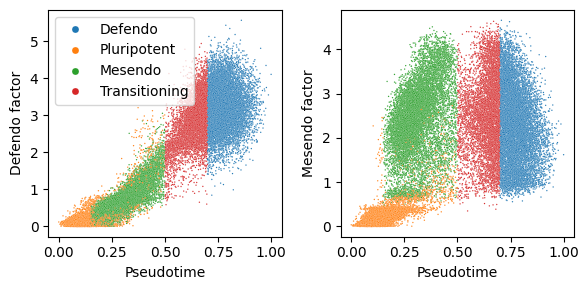

In [19]:



learned_activations = scvi_palava.get_latent_representation()

new_leg_names = {'defendo': 'Defendo',
                 'mesendo': 'Mesendo',
                 'no_stage': 'Transitioning',
                 'ips': 'Pluripotent'
}

plot_df = pd.DataFrame({

        f'dim_0': learned_activations[:,0].flatten(),
        f'dim_1': learned_activations[:,1].flatten(),
        f'dim_2': learned_activations[:,2].flatten(),
       f'dim_unann': learned_activations[:,53+29].flatten(),
    'clusters': adata_norm.obs['cell_differentiation'].map(new_leg_names),
    'pseudotime': adata_norm.obsm['pseudo']
})
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))  # 2 plots side by side

# First scatterplot (dim_0 vs dim_2)
sns.scatterplot(data=plot_df, x='pseudotime', y='dim_2', s=1, hue='clusters', ax=axes[0], rasterized=True)
axes[0].legend(markerscale = 5)  # Optional: remove duplicate legends
axes[0].set_xlabel('Pseudotime')
axes[0].set_ylabel('Defendo factor')

# Second scatterplot (dim_0 vs dim_1)
sns.scatterplot(data=plot_df, x='pseudotime', y='dim_1', s=1, hue='clusters', ax=axes[1], rasterized=True)
axes[1].legend_.remove()  # Optional: remove duplicate legends
axes[1].set_xlabel('Pseudotime')
axes[1].set_ylabel('Mesendo factor')

# Single shared legend
handles, labels = axes[1].get_legend_handles_labels()
#fig.legend(handles, labels, loc='center right', ncol=len(labels), markerscale = 5, bbox_to_anchor=(0.5, 0.5))

plt.tight_layout()
plt.show()
plt.close()

0
[1.1756027936935425 1.0110703706741333 0.9522421360015869
 0.892024576663971 0.8004107475280762 0.7907402515411377
 0.7315242886543274 0.7295540571212769 0.72730553150177 0.7227071523666382
 0.7144472002983093 0.7074829936027527 0.6924200057983398
 0.688194215297699 0.6801888346672058 0.6763601899147034
 0.6716864705085754 0.6690390706062317 0.6593970060348511
 0.6588199734687805 0.6573258638381958 0.6555846929550171
 0.6538666486740112 0.6500113010406494 0.6428107619285583]


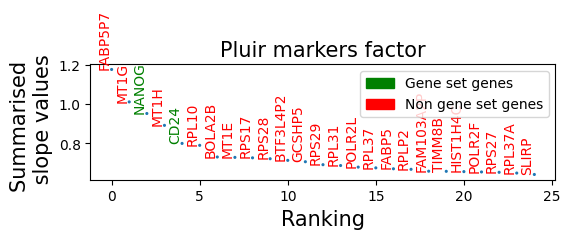

['FABP5P7', 'MT1G', 'NANOG', 'MT1H', 'CD24', 'RPL10', 'BOLA2B', 'MT1E', 'RPS17', 'RPS28', 'BTF3L4P2', 'GCSHP5', 'RPS29', 'RPL31', 'POLR2L', 'RPL37', 'FABP5', 'RPLP2', 'FAM103A2P', 'TIMM8B', 'HIST1H4C', 'POLR2F', 'RPS27', 'RPL37A', 'SLIRP']
1
[0.7957438230514526 0.7209826707839966 0.6563148498535156
 0.6091818809509277 0.6085090637207031 0.5903710722923279
 0.5865039825439453 0.5584554672241211 0.5386505722999573
 0.5358449816703796 0.5348291397094727 0.5344342589378357
 0.5296167731285095 0.5290486812591553 0.5258700251579285
 0.5229498147964478 0.5216459035873413 0.5054478645324707
 0.5024387836456299 0.48391401767730713 0.46725329756736755
 0.46611613035202026 0.4627683460712433 0.4613901376724243
 0.46060097217559814]


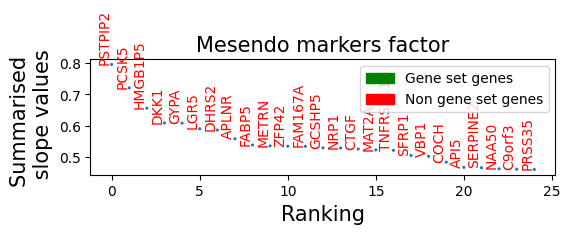

['PSTPIP2', 'PCSK5', 'HMGB1P5', 'DKK1', 'GYPA', 'LGR5', 'DHRS2', 'APLNR', 'FABP5', 'METRN', 'ZFP42', 'FAM167A', 'GCSHP5', 'NRP1', 'CTGF', 'MAT2A', 'TNFRSF11B', 'SFRP1', 'VBP1', 'COCH', 'API5', 'SERPINE2', 'NAA50', 'C9orf3', 'PRSS35']
2
[2.2951979637145996 2.1722676753997803 1.8907115459442139
 1.6415741443634033 1.6259859800338745 1.482560157775879
 1.4753799438476562 1.4357197284698486 1.434471607208252 1.383834958076477
 1.3445013761520386 1.3380683660507202 1.333502173423767
 1.3245991468429565 1.3198117017745972 1.3166100978851318
 1.307553768157959 1.2981936931610107 1.2827789783477783 1.266457438468933
 1.2510753870010376 1.249870777130127 1.2481462955474854
 1.2013696432113647 1.186005711555481]


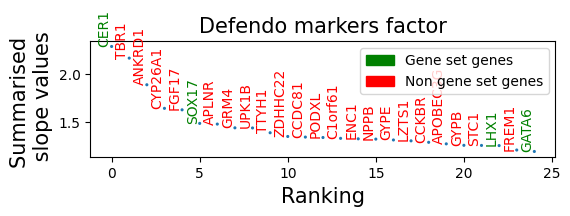

['CER1', 'TBR1', 'ANKRD1', 'CYP26A1', 'FGF17', 'SOX17', 'APLNR', 'GRM4', 'UPK1B', 'TTYH1', 'ZDHHC22', 'CCDC81', 'PODXL', 'C1orf61', 'ENC1', 'NPPB', 'GYPE', 'LZTS1', 'CCKBR', 'APOBEC3G', 'GYPB', 'STC1', 'LHX1', 'FREM1', 'GATA6']
3
[2.859724283218384 2.8214876651763916 2.6541342735290527
 2.4995319843292236 2.3390538692474365 2.237433910369873 2.215188503265381
 2.158783435821533 2.149029016494751 2.007530450820923 1.9346950054168701
 1.863476276397705 1.7549195289611816 1.7391518354415894
 1.7182838916778564 1.4184772968292236 0.9218898415565491
 0.6045727133750916 0.11057031154632568 0.08276217430830002
 0.07565630227327347 0.07447532564401627 0.07251635938882828
 0.06758145987987518 0.06751999258995056]


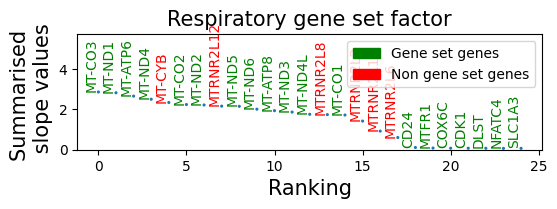

['MT-CO3', 'MT-ND1', 'MT-ATP6', 'MT-ND4', 'MT-CYB', 'MT-CO2', 'MT-ND2', 'MTRNR2L12', 'MT-ND5', 'MT-ND6', 'MT-ATP8', 'MT-ND3', 'MT-ND4L', 'MTRNR2L8', 'MT-CO1', 'MTRNR2L2', 'MTRNR2L1', 'MTRNR2L6', 'CD24', 'MTFR1', 'COX6C', 'CDK1', 'DLST', 'NFATC4', 'SLC1A3']
12
[0.9551107287406921 0.7944393157958984 0.7796452641487122
 0.7490204572677612 0.7332297563552856 0.7145106792449951
 0.7092732191085815 0.6905751824378967 0.6816623210906982
 0.6767454743385315 0.6005390286445618 0.5909217596054077
 0.5669792294502258 0.5539660453796387 0.5457442402839661
 0.5358867645263672 0.5217528939247131 0.4578988254070282
 0.4492451846599579 0.43556052446365356 0.3957015573978424
 0.39032527804374695 0.3731061518192291 0.3559504747390747
 0.2749689817428589]


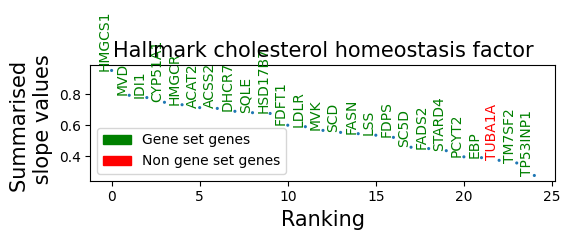

['HMGCS1', 'MVD', 'IDI1', 'CYP51A1', 'HMGCR', 'ACAT2', 'ACSS2', 'DHCR7', 'SQLE', 'HSD17B7', 'FDFT1', 'LDLR', 'MVK', 'SCD', 'FASN', 'LSS', 'FDPS', 'SC5D', 'FADS2', 'STARD4', 'PCYT2', 'EBP', 'TUBA1A', 'TM7SF2', 'TP53INP1']
21
[7.762331485748291 6.430570125579834 6.244373321533203 5.819791316986084
 4.919249534606934 4.305484771728516 4.261471748352051 4.191650390625
 4.13988733291626 3.840217113494873 3.7951767444610596 3.738025665283203
 3.6727004051208496 3.5815324783325195 3.3515398502349854
 3.3462202548980713 3.3156728744506836 3.2896533012390137
 3.0946297645568848 2.9137394428253174 2.689847469329834
 2.6086080074310303 2.548491954803467 2.5167768001556396
 2.4646389484405518]


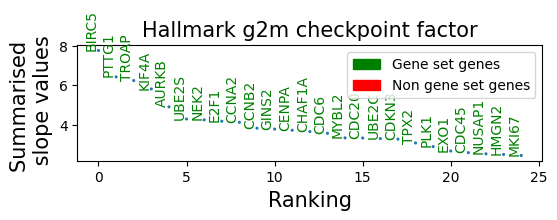

['BIRC5', 'PTTG1', 'TROAP', 'KIF4A', 'AURKB', 'UBE2S', 'NEK2', 'E2F1', 'CCNA2', 'CCNB2', 'GINS2', 'CENPA', 'CHAF1A', 'CDC6', 'MYBL2', 'CDC20', 'UBE2C', 'CDKN3', 'TPX2', 'PLK1', 'EXO1', 'CDC45', 'NUSAP1', 'HMGN2', 'MKI67']
16
[7.642516136169434 6.335986614227295 5.668092727661133 5.230382442474365
 4.364063262939453 4.246679306030273 4.110956192016602 3.805967330932617
 3.6023612022399902 3.587462902069092 3.4604923725128174 3.32366943359375
 3.3174538612365723 3.3126909732818604 3.1484742164611816
 3.012810468673706 2.9707846641540527 2.894293785095215 2.8314504623413086
 2.6551144123077393 2.6359808444976807 2.586846113204956 2.522871494293213
 2.5228281021118164 2.4875197410583496]


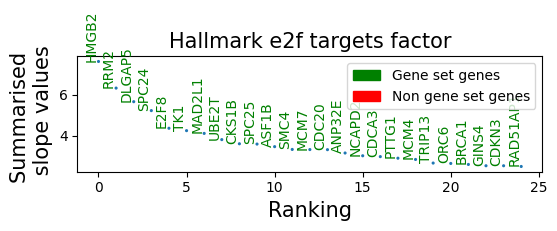

['HMGB2', 'RRM2', 'DLGAP5', 'SPC24', 'E2F8', 'TK1', 'MAD2L1', 'UBE2T', 'CKS1B', 'SPC25', 'ASF1B', 'SMC4', 'MCM7', 'CDC20', 'ANP32E', 'NCAPD2', 'CDCA3', 'PTTG1', 'MCM4', 'TRIP13', 'ORC6', 'BRCA1', 'GINS4', 'CDKN3', 'RAD51AP1']


In [54]:

gene_names = adata.var
num_genes = len(adata.var)

pathways_bool = pathways
path_uann =  torch.zeros(num_genes)
dict_for_co_ocurrence ={}

for fac in [0,1,2,3,12,21,16]:
        print(fac)
        factors = [fac]

        slopes_for_all_fac_lst = scvi_palava.spline_approach(factors = factors)
        slopes_for_all_fac  = {i:j for i, j  in zip(factors,slopes_for_all_fac_lst)}
        

        if fac in [0,1,2]:
            data_1 = np.quantile(abs(slopes_for_all_fac[fac]), q=0.5, axis=0)
        else:
            data_1 = np.quantile(abs(slopes_for_all_fac[fac]), q=0.95, axis=0)

        if fac <50:
            gene_set = pathways_bool[fac].numpy()[None]
        else: 
            gene_set =np.zeros((1,9000))
        data_1_and_de_no_error = np.concatenate((data_1[None],gene_set ,gene_names.index.to_numpy()[None]), axis=0)
        data_1_and_de_no_error = sort_based_on_first_row(data_1_and_de_no_error)
    
        n_top_genes = 25
    
        y = data_1_and_de_no_error[0][:n_top_genes]
        x = np.array([i for i in range(n_top_genes)])
        top_gene_names = [element for element in data_1_and_de_no_error[2][:n_top_genes]]
    

        plt.figure(figsize=(6, 1.5))
        plt.scatter(x, y, s = 5, edgecolor='none')
        print(y)
        # plotting pathway genes
        pathway_gene_ind = data_1_and_de_no_error[1][:n_top_genes] == 1
        
        plt.xlabel('Ranking', fontsize =15)
        plt.ylabel('Summarised \n slope values', fontsize =15)
        plt.title(pathway_names_plot[fac].split('[')[0]+ 'factor', fontsize =15)
        
        
        
        top_gene_names = [element.split('_')[1] for element in data_1_and_de_no_error[2][:n_top_genes]]
        for i, txt in enumerate(top_gene_names):
             color = ['r', 'g'][int(data_1_and_de_no_error[1][i])]      
             plt.annotate(txt, (x[i], y[i]), ha = 'right', va = 'bottom', rotation = 90, fontsize = 10, color = color)
        geneset = mpatches.Patch(color='g', label='Gene set genes')
        nongeneset = mpatches.Patch(color='r', label='Non gene set genes')
        if 'Resp' in pathway_names_plot[fac]: # Resp genes have long name
            plt.ylim(0,np.max(y) * 2)
        plt.legend(handles=[geneset, nongeneset])
        plt.show()
        plt.close()
        print(np.array(top_gene_names)[:n_top_genes].tolist())
        count = 0 
        dict_for_co_ocurrence[pathway_names_plot[fac]] = np.array(top_gene_names)[:n_top_genes].tolist()


3


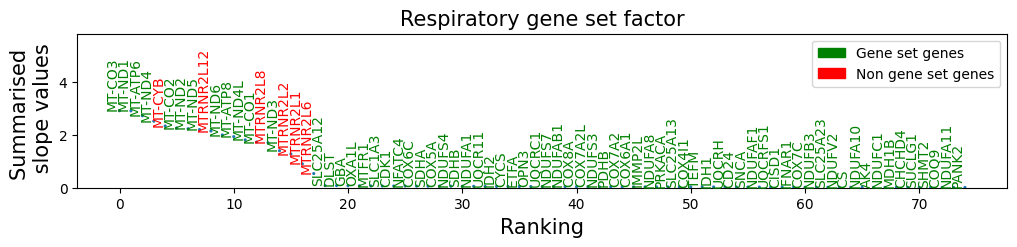

In [94]:

gene_names = adata.var
num_genes = len(adata.var)

pathways_bool = pathways
path_uann =  torch.zeros(num_genes)


for fac in [3]:#np.argsort(factor_importance[:54])[::-1][:20]:
        print(fac)
        factors = [fac]

        slopes_for_all_fac_lst = scvi_palava.spline_approach(factors = factors)
        slopes_for_all_fac  = {i:j for i, j  in zip(factors,slopes_for_all_fac_lst)}
        


        data_1 = np.quantile(abs(slopes_for_all_fac[fac]), q=0.95, axis=0)
        if fac <50:
            gene_set = pathways_bool[fac].numpy()[None]
        else: 
            gene_set =np.zeros((1,9000))
        data_1_and_de_no_error = np.concatenate((data_1[None],gene_set ,gene_names.index.to_numpy()[None]), axis=0)
        data_1_and_de_no_error = sort_based_on_first_row(data_1_and_de_no_error)
    
        n_top_genes = 75
    
        y = data_1_and_de_no_error[0][:n_top_genes]
        x = np.array([i for i in range(n_top_genes)])
        top_gene_names = [element for element in data_1_and_de_no_error[2][:n_top_genes]]
    

        plt.figure(figsize=(12, 2))
        plt.scatter(x, y, s = 5, edgecolor='none')
    
        # plotting pathway genes
        pathway_gene_ind = data_1_and_de_no_error[1][:n_top_genes] == 1
        
        plt.xlabel('Ranking', fontsize =15)
        plt.ylabel('Summarised \n slope values', fontsize =15)
        plt.title(pathway_names_plot[fac].split('[')[0]+ 'factor', fontsize =15)
        
        
        
        top_gene_names = [element.split('_')[1] for element in data_1_and_de_no_error[2][:n_top_genes]]
        for i, txt in enumerate(top_gene_names):
             color = ['r', 'g'][int(data_1_and_de_no_error[1][i])]      
             plt.annotate(txt, (x[i], y[i]), ha = 'right', va = 'bottom', rotation = 90, fontsize = 10, color = color)
        geneset = mpatches.Patch(color='g', label='Gene set genes')
        nongeneset = mpatches.Patch(color='r', label='Non gene set genes')
        if 'Resp' in pathway_names_plot[fac]: # Resp genes have long name
            plt.ylim(0,np.max(y) * 2)
        plt.legend(handles=[geneset, nongeneset])
        plt.show()
        plt.close()
        count = 0

DE...: 100%|██████████| 3/3 [00:13<00:00,  4.36s/it]
Marker genes for the different clusters


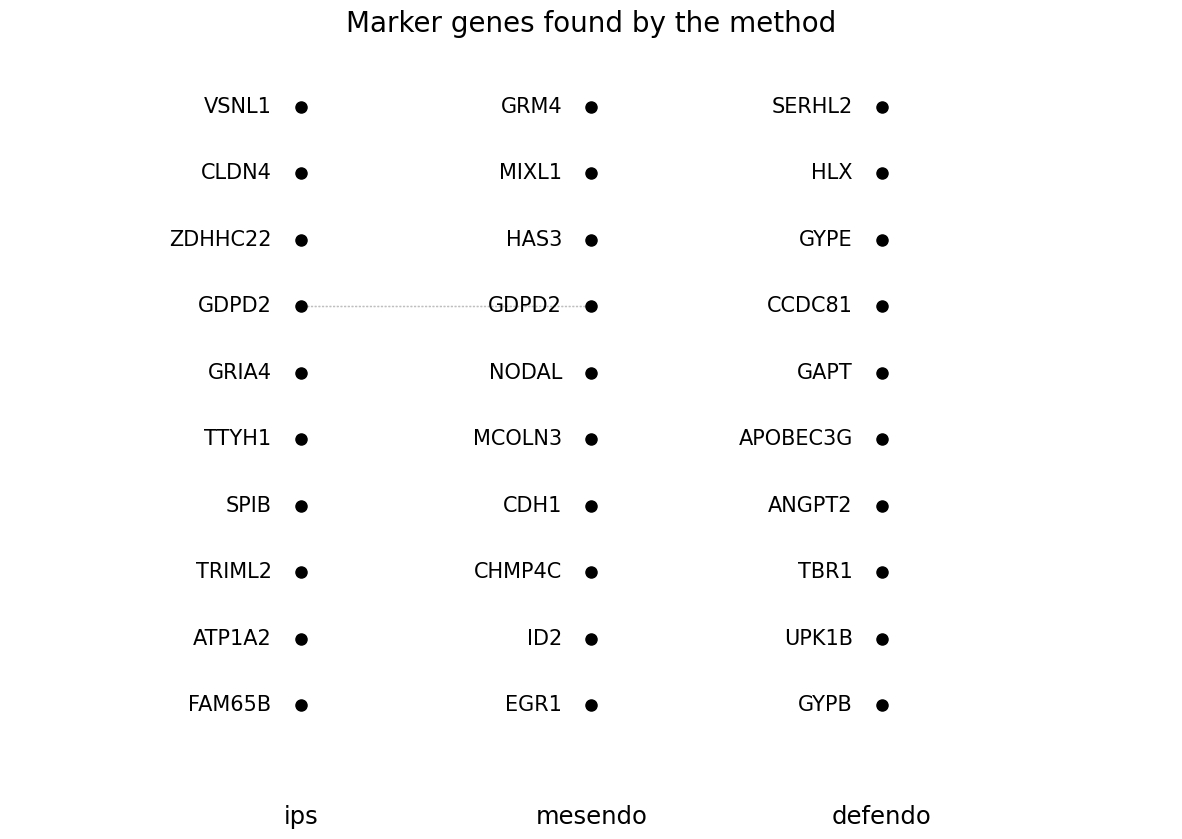

In [95]:

#adata.obs['clusters_fine']

group1 =  ['ips','mesendo', 'defendo']
de_df = scvi_palava.differential_expression( delta = 0.05, groupby ='cell_differentiation', group1 =  group1, n_samples = 7000,  mode='change', path_index = [ 0,1,2])#  path_index = [ 51]
markers = {} # Dictionary to save the markers
cats = group1
for c in cats:
    cid = f"{c} vs Rest"
    cell_type_df = de_df.loc[de_df.comparison == cid]

    cell_type_df = cell_type_df[cell_type_df.lfc_mean > 0] 
    cell_type_df = cell_type_df[cell_type_df["bayes_factor"] > 3] 
    cell_type_df = cell_type_df[cell_type_df["non_zeros_proportion1"] > 0.1] 
    cell_type_df = cell_type_df.sort_values(by='lfc_mean', ascending=False)
    markers[c] = cell_type_df.index.tolist()[:10]
print('Marker genes for the different clusters')

def plot_multiple_ranks(data, colors=None, labels_offset=0.1, arrow_len=0, y_spacing=1, 
                        draw_uncolored_edges=True, title='', show_uncolored_nodes=True, color_legend=None):
    """
    Plots ranked lists with connections and optional coloring and legend.
    
    Parameters:
    - data: dict
        A dictionary where keys are list names and values are ranked lists.
    - colors: dict, optional
        A dictionary mapping items to colors.
    - labels_offset: float, optional
        Horizontal offset for text labels.
    - arrow_len: float, optional
        Arrowhead length for connections.
    - y_spacing: float, optional
        Vertical spacing between nodes.
    - draw_uncolored_edges: bool, optional
        Whether to draw edges for uncolored nodes.
    - title: str, optional
        Title for the plot.
    - show_uncolored_nodes: bool, optional
        Whether to display labels for uncolored nodes.
    - color_legend: dict, optional
        A dictionary mapping colors to legend labels (e.g., {'red': 'Beta', 'green': 'Delta'}).
    """
    import numpy as np
    import matplotlib.patches as mpatches
    
    keys = list(data.keys())  # Extract the keys from the dictionary
    num_lists = len(keys)  # Number of input lists
    fig, ax = plt.subplots(figsize=(15, 9.5))
    
    ax.set_xlim(0, num_lists + 1)  # Adjust x-limits based on the number of lists
    max_len = max(len(lst) for lst in data.values())  # Maximum length of all lists
    
    # Reverse the order of each list
    reversed_data = {key: lst[::-1] for key, lst in data.items()}

    # Align all lists from the top by setting y-values relative to max_len
    y_values = []
    for key in keys:
        list_len = len(reversed_data[key])
        start_y = (max_len - list_len) * y_spacing  # Top-align shorter lists
        y_values.append(np.arange(start_y + y_spacing, start_y + (list_len + 1) * y_spacing, y_spacing))
    
    ax.set_ylim(0, (max_len + 1) * y_spacing)  # Set y-limits based on max list size
    
    ax.axis('off')  # Remove axes

    # Draw arrows between the lists
    for i in range(num_lists - 1):  # Loop through each adjacent pair of lists
        current_list = reversed_data[keys[i]]
        next_list = reversed_data[keys[i + 1]]
        
        # Map current list items to their positions in the next list
        current_to_next = [next_list.index(item) if item in next_list else None for item in current_list]
        
        for j in range(len(current_list)):
            if current_to_next[j] is not None:
                edge_color = colors.get(current_list[j], 'black') if colors else 'black'
                
                # Skip uncolored edges if requested
                if edge_color == 'black' and not draw_uncolored_edges:
                    continue
                
                # Draw the arrow
                ax.arrow(i + 1.02, y_values[i][j], 
                         0.96, y_values[i + 1][current_to_next[j]] - y_values[i][j], 
                         head_width=arrow_len, head_length=arrow_len, 
                         fc=edge_color, ec=edge_color, length_includes_head=True, linestyle=':', alpha=0.25)

    # Plot nodes and labels
    for i, key in enumerate(keys):
        lst = reversed_data[key]
        for j in range(len(lst)):
            ax.plot(i + 1, y_values[i][j], 'o', markersize=8, color='black')  # Nodes
            
            text_color = colors.get(lst[j], 'black') if colors else 'black'
            if text_color != 'black' or show_uncolored_nodes:
                ax.text(i + 1 - labels_offset, y_values[i][j], lst[j], 
                        verticalalignment='center', horizontalalignment='right', color=text_color, fontsize=15)

        # Add column label
        ax.text(i + 1, -0.5, key, verticalalignment='top', horizontalalignment='center', fontsize=17.5)

    # Add title
    plt.title(title, fontsize=20)

    # Add legend
    if color_legend:
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in color_legend.items()]
        ax.legend(handles=legend_patches, loc='upper right', fontsize=15, title="Legend", bbox_to_anchor=(0.65, 0., 0.5, 0.5))

    plt.show()

markers_symb = markers.copy()

for key in markers.keys():
    
    markers_symb[key] = [i.split('_')[1] for i in markers[key]]
plot_multiple_ranks(markers_symb,  draw_uncolored_edges=True,show_uncolored_nodes=True, title = 'Marker genes found by the method')


# linear regression on unnannotated latent variables 

In [65]:
from sklearn.preprocessing import normalize
def minmax(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

dict_of_features = adata.obsm.as_dict()

for k in list(dict_of_features.keys()):
    if 'X_' in k: # usually dimesnion reduction output 
        dict_of_features.pop(k)
        print('removing  dimesnion reduction output', k)
        continue 
    if len(list(set(dict_of_features[k])))==1:# or not np.issubdtype(dict_of_features[k].dtype, np.number):
        print('Only one value:',k)
        dict_of_features.pop(k)
        continue 
    
    if not np.issubdtype(dict_of_features[k].dtype, np.number) and len(list(set(dict_of_features[k]))) > 5000:
        print('String features with large number of unique feature values:',k)
        dict_of_features.pop(k)
        continue 
        
    if np.issubdtype(dict_of_features[k].dtype, np.number) and np.isnan(dict_of_features[k]).any():
        print('Contains NAN:',k)
        dict_of_features.pop(k)
        continue
    #if 'PC1' in k:
    #    print('removing PC1:',k)
    #    dict_of_features.pop(k)
    #    continue

print('\n'*5)
df = pd.DataFrame(dict_of_features)

dict_of_one_hot_names ={}

for col in df.columns:
    if not np.issubdtype(df[col].dtype, np.number):
        print(col)
        col_one_hot =  pd.get_dummies(df[col]).astype(int)
        dict_of_one_hot_names[col] = col_one_hot.columns
        del df[col]
        df = pd.concat([df, col_one_hot], axis=1)
        print('One hot enoded feature: ', col)
    else:
        arr = df[col]
        df[col] = minmax(arr)#(arr - arr.min()) / (arr.max() - arr.min())



latent_all = latent

feature_names = list(df.columns)
# range of unannotaterd latent varibales
min_ind =54
max_ind =94
latent_unann = latent_all[:, min_ind:max_ind]

latent_names = ['latent_' + str(i) for i in range(min_ind,max_ind)]
df_latent = pd.DataFrame(latent_unann, columns = latent_names)
df = pd.concat([df, df_latent], axis=1)


/tmp/ipykernel_191006/1743042045.py:5: FutureWarning: Use dict(obj) instead of AlignedMapping.as_dict, AlignedMapping.as_dict is deprecated and will be removed in the future.
  dict_of_features = adata.obsm.as_dict()


Only one value: assigned
Only one value: auxDir
Only one value: cell_filter
String features with large number of unique feature values: cell_name
Only one value: expected_format
Only one value: frag_dist_length
Only one value: gc_bias_correct
Only one value: is_cell_control
Only one value: is_cell_control_bulk
Only one value: is_cell_control_control
Only one value: libType
Only one value: library_types
Only one value: mapping_type
String features with large number of unique feature values: mates1
String features with large number of unique feature values: mates2
Only one value: num_bias_bins
Only one value: num_bootstraps
Only one value: num_libraries
Only one value: num_targets
Contains NAN: pct_counts_top_50_features_ERCC
String features with large number of unique feature values: plate_well_id
String features with large number of unique feature values: public_name
String features with large number of unique feature values: read_files
Only one value: salmon_version
Only one value: sa

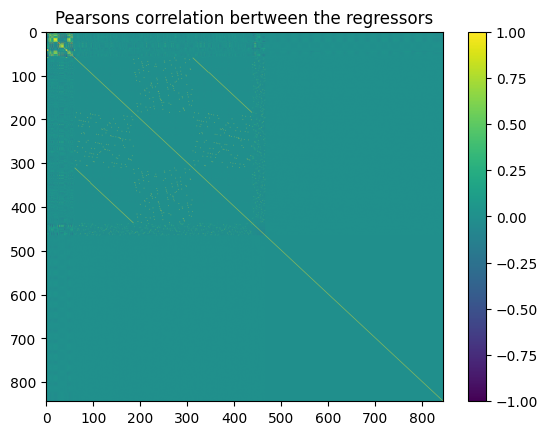

In [52]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Extract the features (X) and the target variable (y)
X = df[feature_names]  # Replace with your feature columns
y = df[latent_names]  # Replace with your target column



plt.imshow(np.corrcoef(X.T), aspect='auto')
plt.title('Pearsons correlation bertween the regressors')
plt.colorbar()



In [66]:

print('Regressors with a very high correlation with each other')
corr = np.corrcoef(X.T)
corr_ind =  np.where(np.corrcoef(X.T)>0.99)
for i,j in zip(corr_ind[0], corr_ind[1]):
   if i<j:
     print(feature_names[i], '\t',feature_names[j],'\t', corr[i, j] )

Regressors with a very high correlation with each other
PC1_top1000hvgs 	 PC1_top2000hvgs 	 0.9969194769483413
PC1_top1000hvgs 	 PC1_top200hvgs 	 0.9915168040481848
PC1_top1000hvgs 	 PC1_top500hvgs 	 0.9974378001855922
PC1_top1000hvgs 	 pseudo 	 0.9901001800204429
PC1_top100hvgs 	 PC1_top200hvgs 	 0.996799906911869
PC1_top100hvgs 	 PC1_top500hvgs 	 0.9908055623457729
PC1_top200hvgs 	 PC1_top500hvgs 	 0.9972451251475257
log10_total_features 	 log10_total_features_endogenous 	 0.9998672733656919
log10_total_features 	 total_features 	 0.9944907078125556
log10_total_features 	 total_features_endogenous 	 0.9945055629406493
log10_total_features_MT 	 total_features_MT 	 0.9978358379070867
log10_total_features_endogenous 	 total_features 	 0.9941053644140442
log10_total_features_endogenous 	 total_features_endogenous 	 0.9943811562913623
num_assigned_fragments 	 num_compatible_fragments 	 0.9999999405253058
num_assigned_fragments 	 num_mapped 	 1.0
num_assigned_fragments 	 total_counts 	 0.9

In [140]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Extract the features (X) and the target variable (y)
X = df[feature_names]  # Replace with your feature columns
y = df[latent_names]  # Replace with your target column


for col in y.columns:
    y[col] = minmax(y[col])
    
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1)

# Create a linear regression model
model =  Ridge(alpha =1)

# Fit the model to the training data
mdoel = model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

/tmp/ipykernel_191006/88384027.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[col] = minmax(y[col])


Mean Squared Error: 0.01
R-squared (R2) Score: 0.48


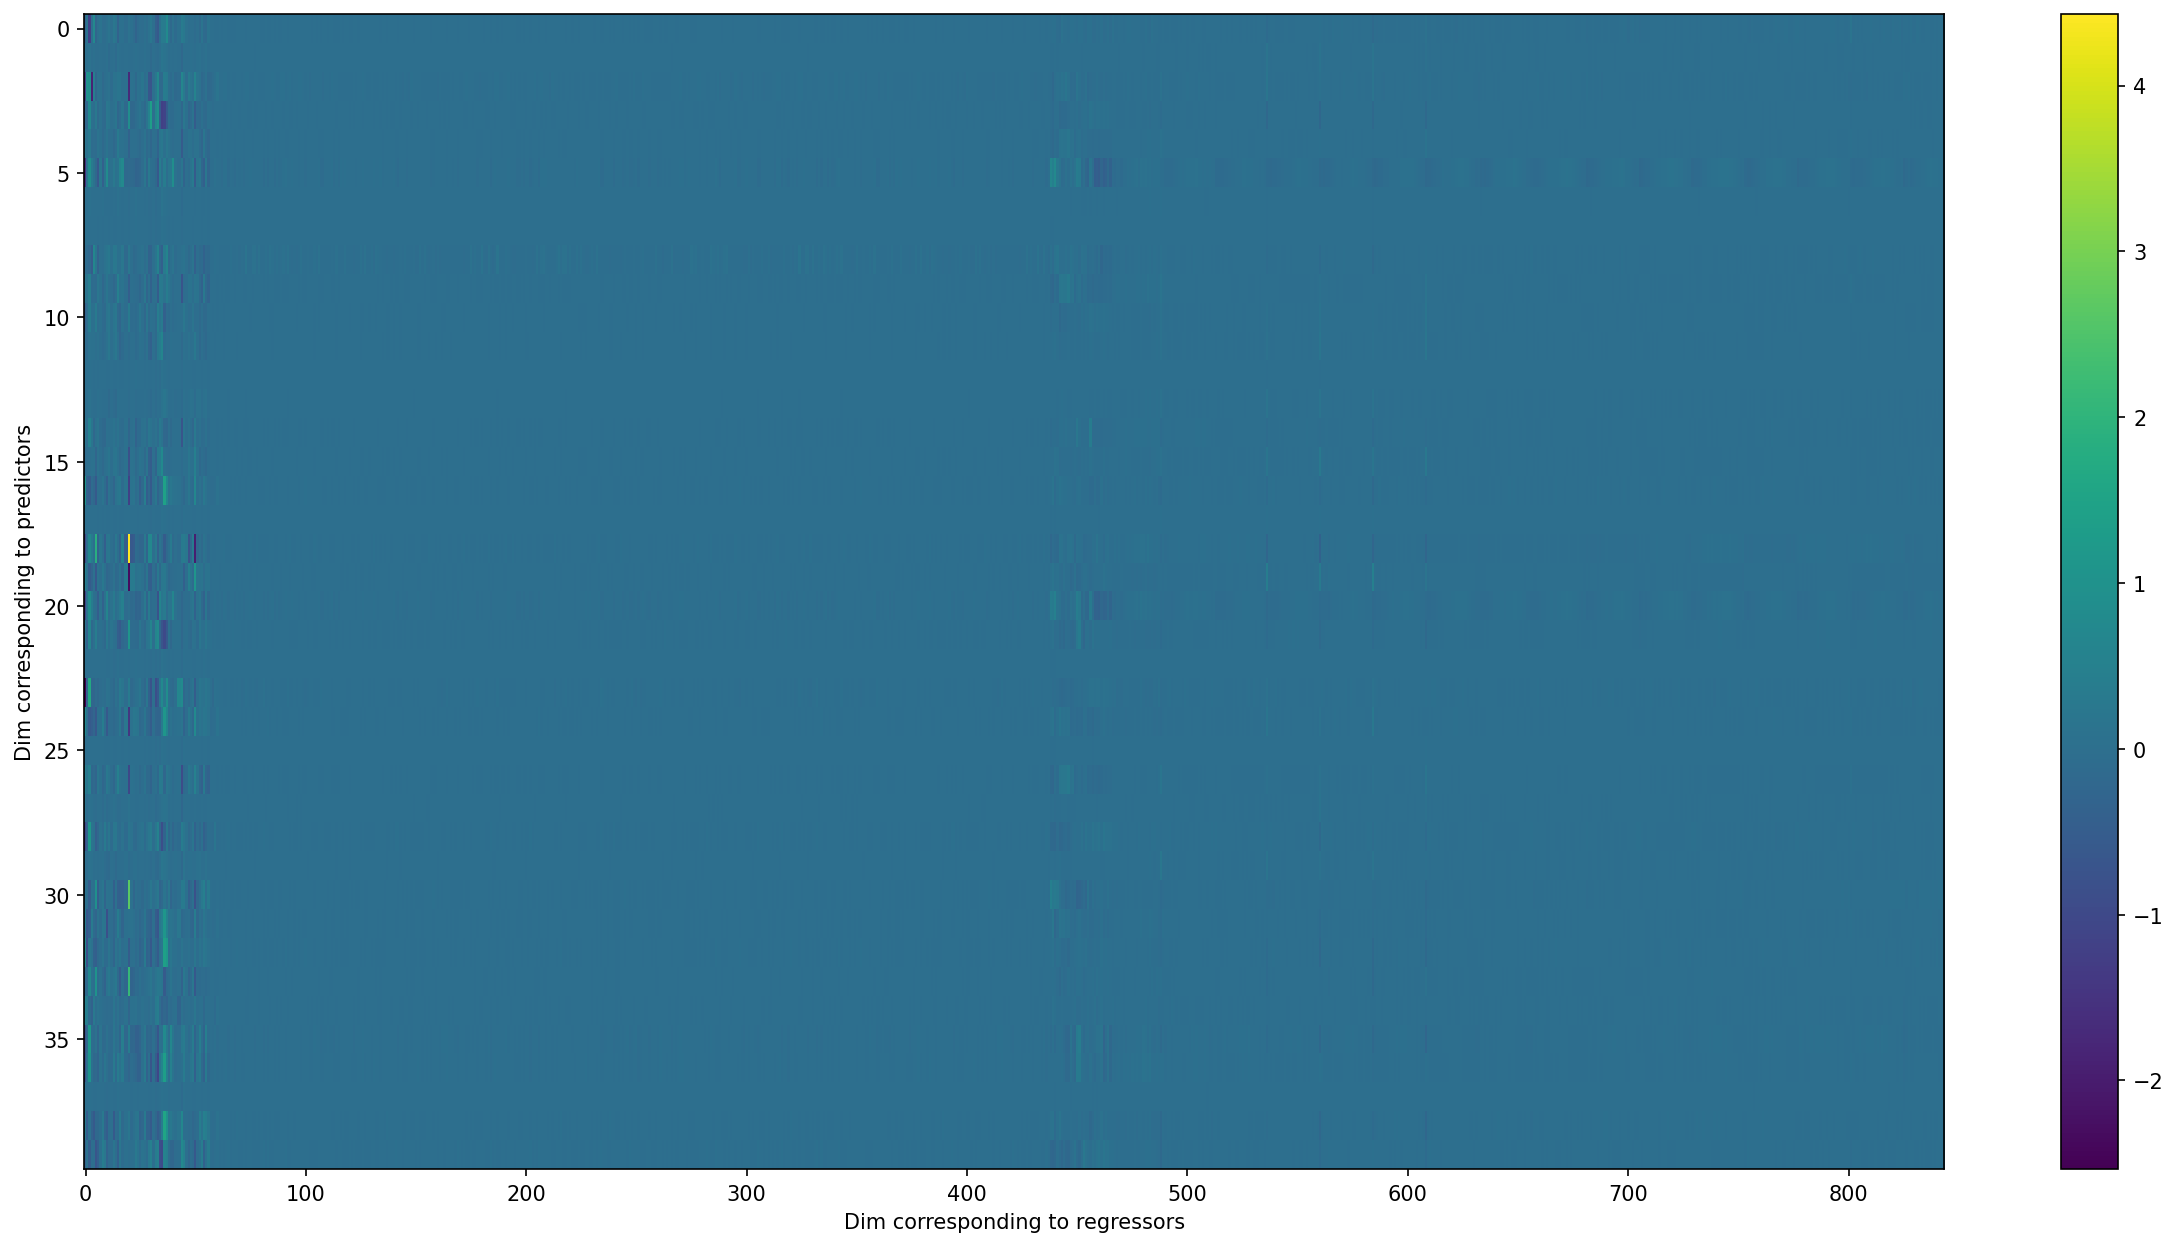

In [146]:

plt.figure(figsize=(20, 10),dpi =150)
plt.xlabel('Dim corresponding to regressors')
plt.ylabel('Dim corresponding to predictors')

plt.imshow(model.coef_, aspect ='auto', interpolation ='none')
plt.colorbar()

In [141]:
for i in range(0, 40):
    print('\n latent varibale '+str(i+54), ' Unannotated var ' +str(i +1))
    ind  = model.coef_[i,:].argsort()[-5:][::-1]
 #np.where(abs(model.coef_[i,:]) > 1)[0]
    for j in ind:
        print('\t',feature_names[j],model.coef_[i,j])


 latent varibale 54  Unannotated var 1
	 pct_counts_top_50_features_endogenous 0.7971162463351954
	 PC1_top500hvgs 0.7136139241619507
	 pct_counts_top_500_features_endogenous 0.3734432594348787
	 pseudo 0.3634479685882985
	 pct_counts_top_50_features 0.3605531325523685

 latent varibale 55  Unannotated var 2
	 pct_counts_top_500_features_endogenous 0.18446986345823396
	 C24 0.1558938828266116
	 E24 0.14212758447854754
	 pct_counts_top_50_features 0.12161315572648994
	 D24 0.11225352133562257

 latent varibale 56  Unannotated var 3
	 PC1_top100hvgs 0.9888831988271738
	 PC1_top2000hvgs 0.92647307932563
	 pct_counts_top_200_features_endogenous 0.7209229643186886
	 pseudo 0.6753866864840533
	 total_counts_endogenous 0.5941990590893139

 latent varibale 57  Unannotated var 4
	 pct_counts_top_100_features_endogenous 1.402519058597954
	 pct_counts_top_200_features_endogenous 0.9588873375370421
	 num_consistent_mappings 0.8797401609047407
	 PC1_top2000hvgs 0.7824076169292223
	 pct_counts_top_

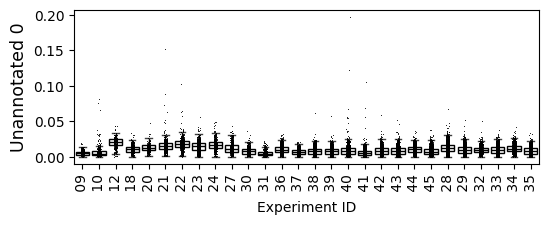

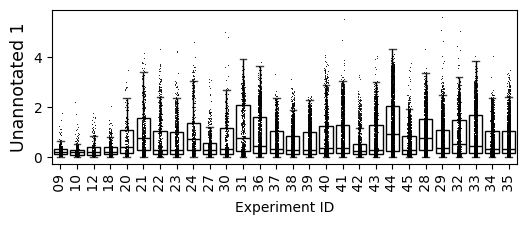

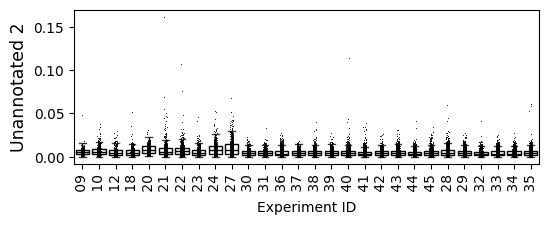

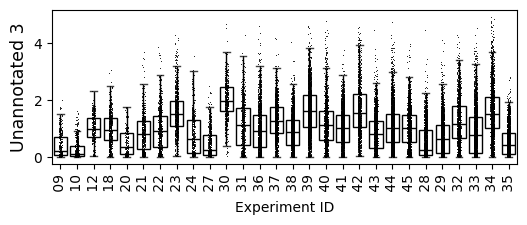

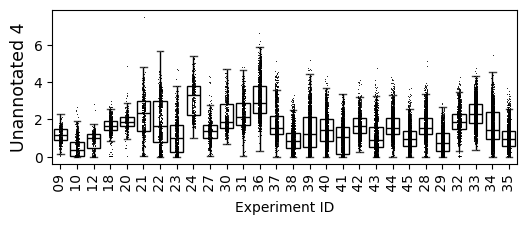

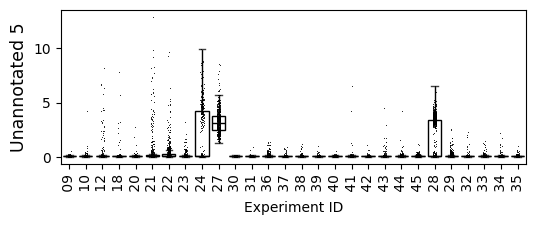

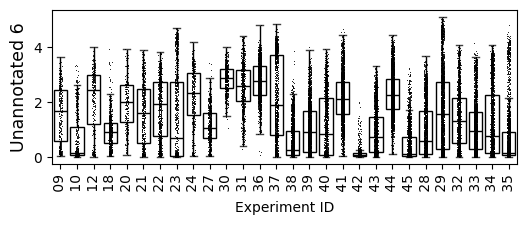

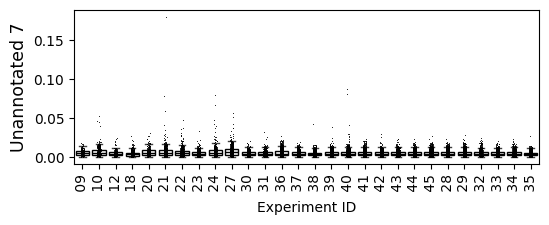

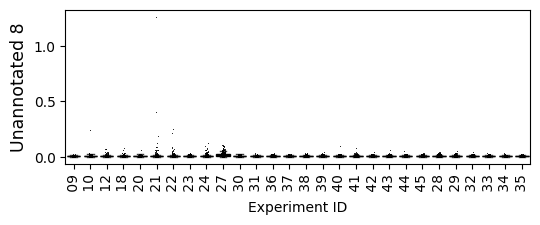

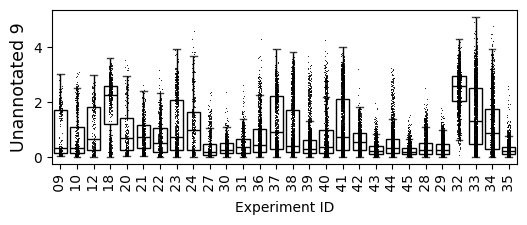

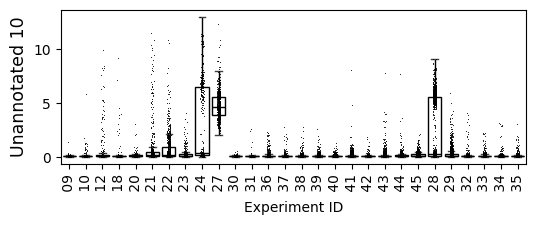

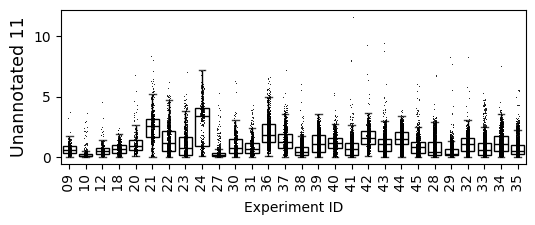

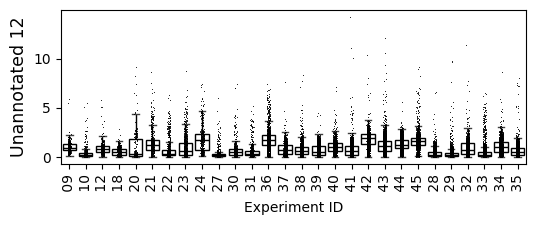

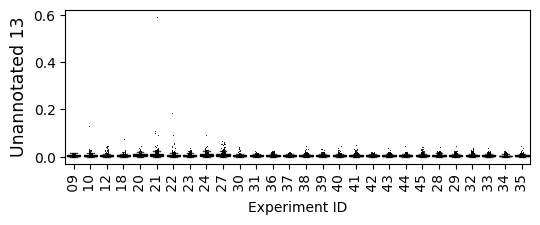

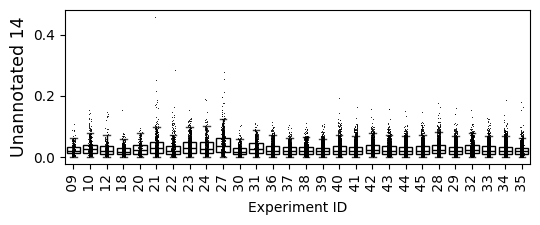

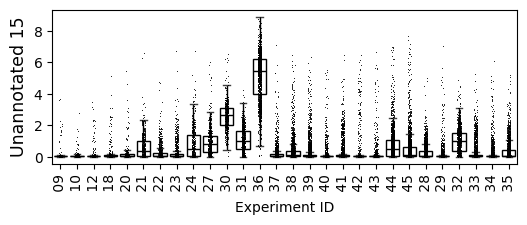

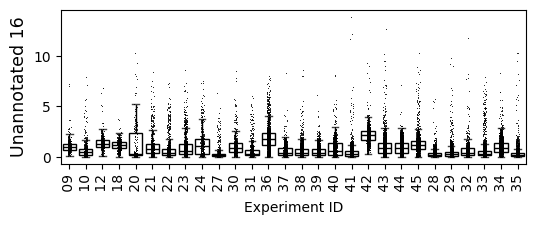

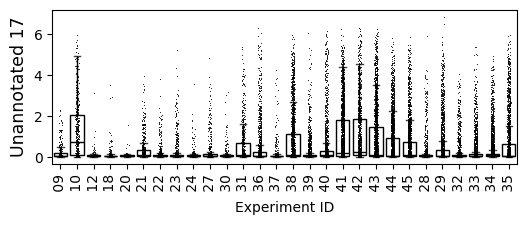

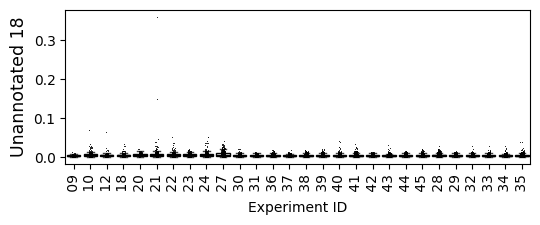

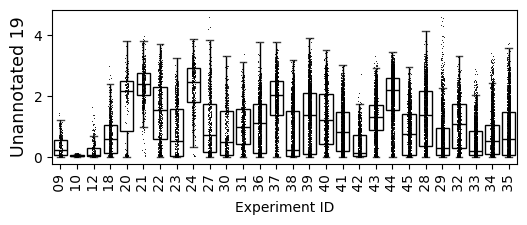

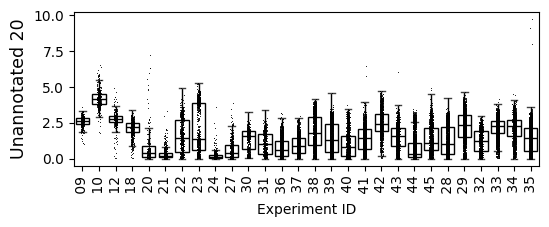

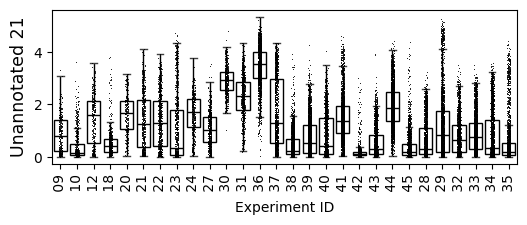

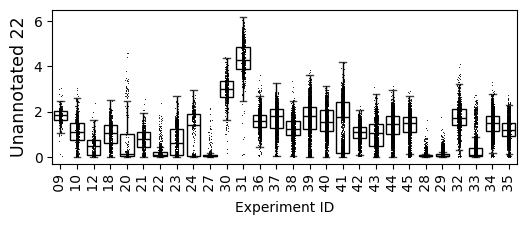

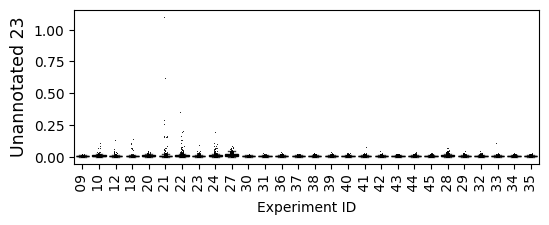

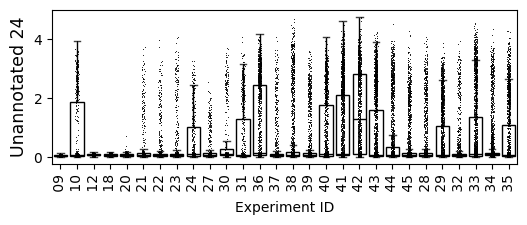

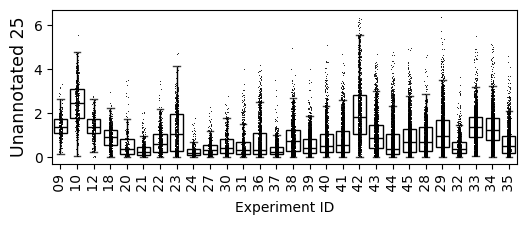

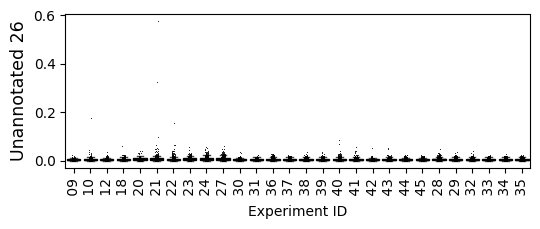

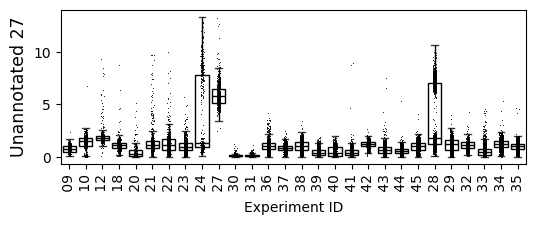

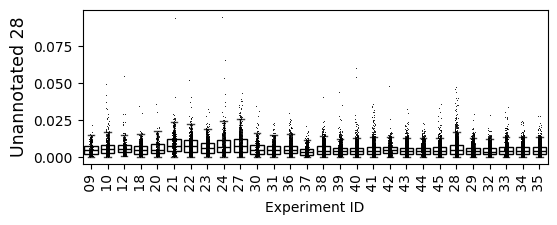

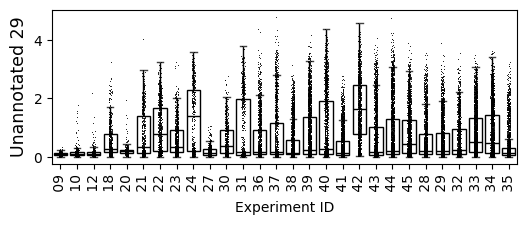

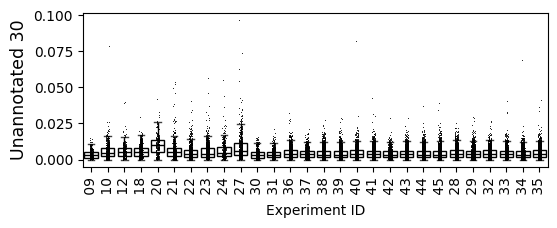

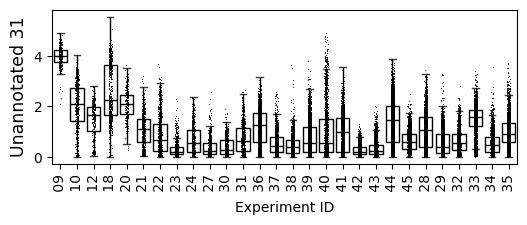

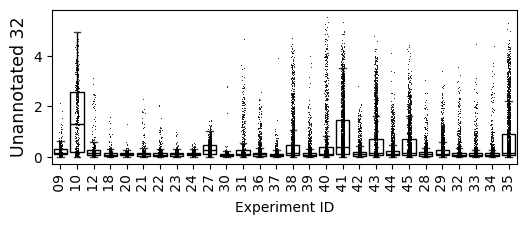

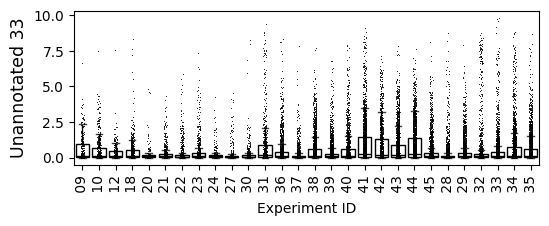

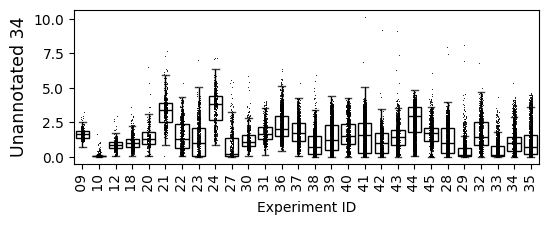

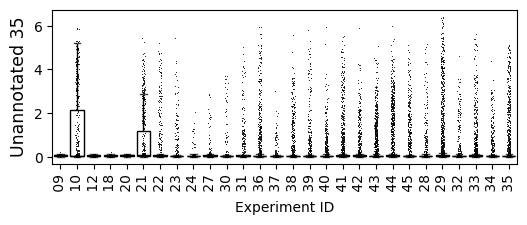

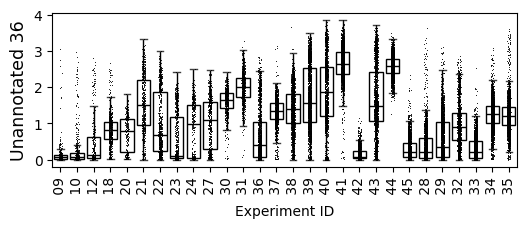

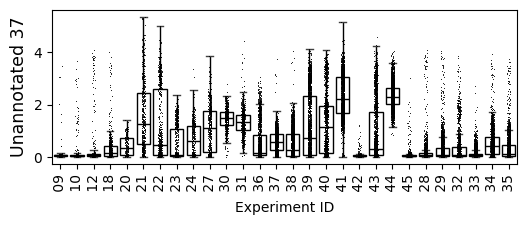

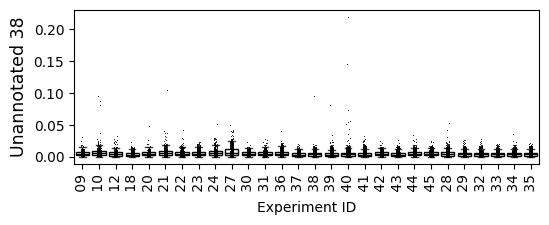

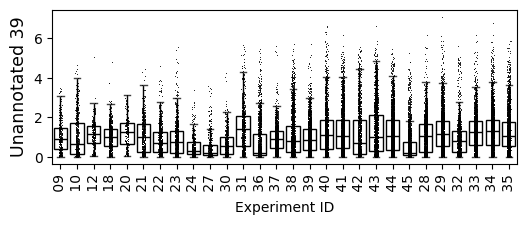

In [149]:

import seaborn as sns

formatted_experiments = (
    pd.Series(adata.obsm["experiment"])
    .str.replace('_', ' ', regex=False)
    .str.replace('expt', '', regex=False)
)
for fac in range(40): 
 #   fac = 18 #60 #80 #76 #80 
    fac += 53
    data_v = pd.DataFrame({'Category': formatted_experiments, 'Num' : latent[:, fac]})
    
    plt.figure(figsize=(6, 2))  # Adjust the figure size as needed
    sns.stripplot(x='Category', y= 'Num', data=data_v, c='k', s=0.75)
    sns.boxplot(
    data=data_v,
    y='Num',
    x='Category',
    showcaps=True,
    boxprops={'facecolor': 'none', 'edgecolor': 'black'},  # no fill, black border
    whiskerprops={'color': 'black'},
    medianprops={'color': 'black'},
    flierprops={'marker': ''},  # hide outliers from boxplot
)
    plt.title('')
    plt.xticks(rotation=90)
    plt.xlabel('Experiment ID')
    plt.ylabel('Unannotated ' + str(fac -53 ), fontsize = 12.5)
    plt.show()
